In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/kenya.csv")

df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [6]:
# Add country column
df["Country"] = "Kenya"

# Convert YEAR + DOY into proper date
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

# Extract month
df["Month"] = df["Date"].dt.month

# Check result
df[["YEAR", "DOY", "Date", "Month", "Country"]].head()

,YEAR,DOY,Date,Month,Country
0,2015,1,2015-01-01,1,Kenya
1,2015,2,2015-01-02,1,Kenya
2,2015,3,2015-01-03,1,Kenya
3,2015,4,2015-01-04,1,Kenya
4,2015,5,2015-01-05,1,Kenya


In [7]:
# Replace -999 with NaN
df.replace(-999, np.nan, inplace=True)

print("Missing values after replacing -999:")
print(df.isna().sum())

print("\n----------------------")

# Check duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Drop duplicates if found
df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:")
print(df.shape)

Missing values after replacing -999:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

----------------------
Number of duplicate rows: 0

Dataset shape after removing duplicates:
(4108, 15)


Data Cleaning
Replaced -999 values with NaN.
No missing values were found.
No duplicate rows were found.
Dataset contains 4,108 records after cleaning.
Insight

The Kenya dataset was clean and ready for analysis

In [8]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


In [9]:
df.describe(include=[np.number])

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,6.423564
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,3.477046
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,12.000000


Descriptive Statistics
Average temperature: ~20.43°C

Maximum temperature: ~34.27°C

Minimum temperature: ~8.97°C

Average rainfall: ~1.47 mm

Average humidity: ~65.85%

Maximum wind speed: ~7.59 m/s
Insight



In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Percentage Per Column:")
print(missing_percentage)

print("\nColumns with more than 5% missing values:")
print(missing_percentage[missing_percentage > 5])

Missing Percentage Per Column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64

Columns with more than 5% missing values:
Series([], dtype: float64)


Missing Value Analysis
Missing values in all columns: 0%
No column had more than 5% missing values
Insight

The Kenya dataset had no missing values, so no additional missing value treatment was required.

In [11]:
from scipy.stats import zscore

columns_to_check = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

z_scores = df[columns_to_check].apply(zscore)

outliers = (abs(z_scores) > 3).any(axis=1)

print("Number of outlier rows:")
print(outliers.sum())

Number of outlier rows:
121


Outlier Analysis


Detected 121 outlier rows using the Z-score method.


Insight
These outliers may represent extreme weather conditions such as unusual rainfall or temperature changes, so they were retained for analysis.

In [12]:
# Drop rows where more than 30% values are missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill remaining missing values
df = df.ffill()

print("Remaining missing values:")
print(df.isna().sum())

Remaining missing values:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


### Missing Value Handling

Dropped rows with more than 30% missing values.

Applied forward fill for remaining missing values.

Final dataset has 0 missing values in all columns.
Insight

The dataset is fully cleaned and ready for further analysis.

In [13]:
df.to_csv("../data/kenya_clean.csv", index=False)

print("Cleaned Kenya dataset exported successfully!")

Cleaned Kenya dataset exported successfully!


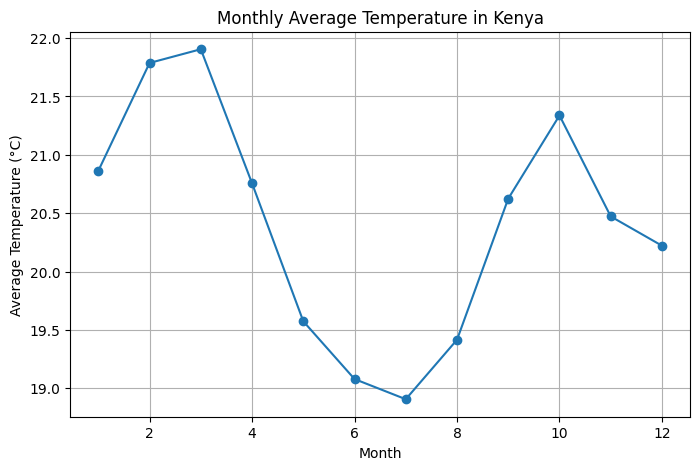

In [14]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(8,5))
monthly_temp.plot(marker="o")
plt.title("Monthly Average Temperature in Kenya")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

### Monthly Temperature Trend Interpretation

Temperature rises from January to March.
March is the warmest month (~21.9°C).
Temperature decreases from April to July.
July is the coolest month (~18.9°C).
Temperature increases again from August to October before slightly declining.
Insight

Kenya experiences moderate temperatures throughout the year with small seasonal variations.

In [15]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

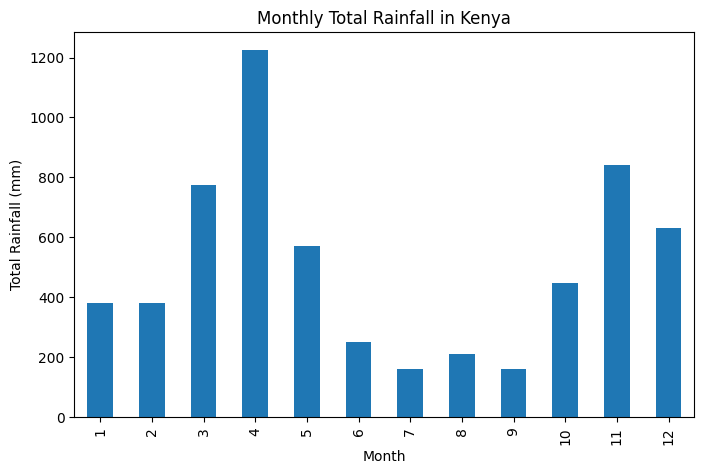

In [16]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(8,5))
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall in Kenya")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.show()

### Rainfall Trend Interpretation

Rainfall increases from January to April.
April recorded the highest rainfall (~1,220 mm).
Rainfall decreases from May to September.
Rainfall rises again in October to December.
November also shows high rainfall levels.
Insight

Kenya experiences two rainy seasons, with the major peak in April and another rainfall increase toward the end of the year.

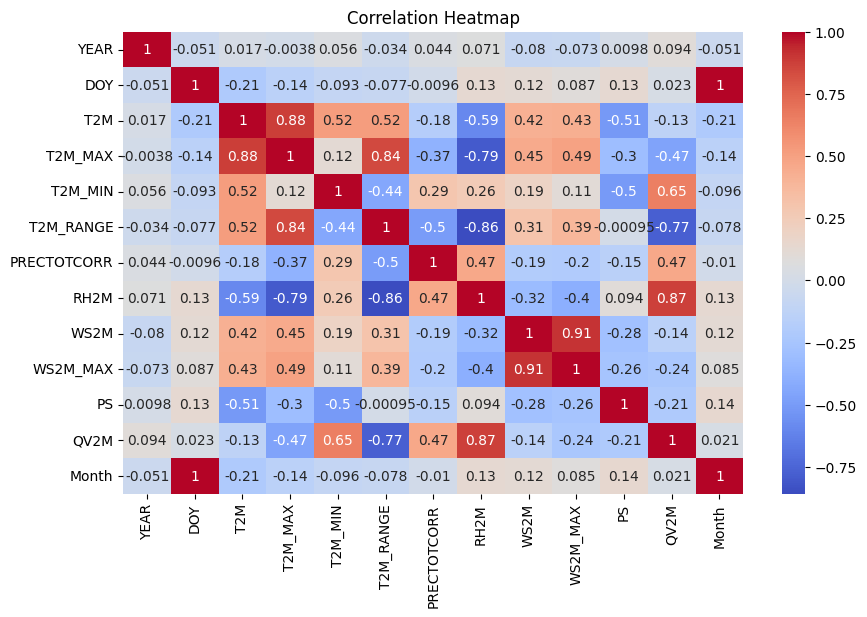

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Interpretation

T2M and T2M_MAX = 0.88 → Higher average temperature leads to higher maximum temperature.
WS2M and WS2M_MAX = 0.91 → Average wind speed strongly relates to maximum wind speed.
RH2M and QV2M = 0.87 → Higher humidity is associated with more moisture in the air.
Insight

The heatmap shows strong relationships between temperature, wind speed, and humidity variables in Kenya’s climate data.

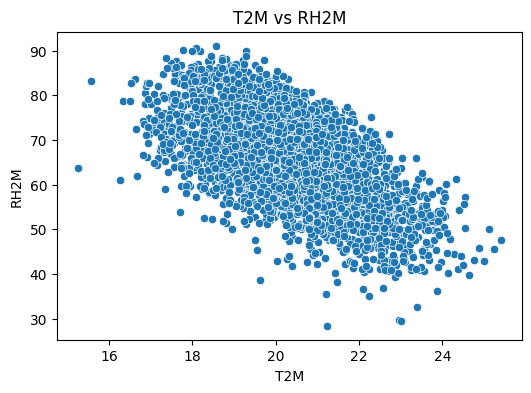

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

### Scatter Plot Interpretation: Temperature vs Humidity

The scatter plot shows a negative relationship between temperature and humidity.
As temperature increases, humidity generally decreases.
Most data points are concentrated between 18°C–23°C temperature and 50%–80% humidity.
Insight

This suggests that hotter days in Kenya tend to have lower humidity, while cooler days are usually more humid

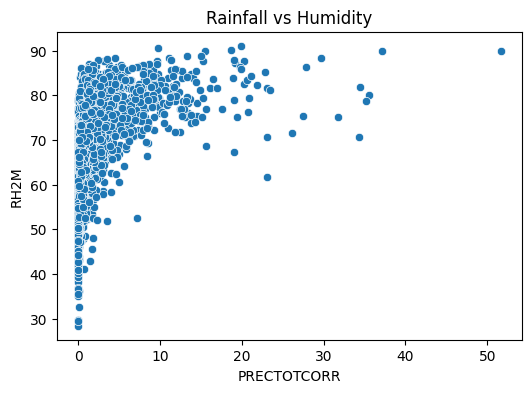

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="PRECTOTCORR", y="RH2M")
plt.title("Rainfall vs Humidity")
plt.show()

### Scatter Plot Interpretation: Rainfall vs Humidity
Higher rainfall mostly occurs when humidity is high.

Most rainfall values are low, but a few extreme rainfall events are present.

Many data points are concentrated at low rainfall levels with humidity between 60%–85%.
Insight

This suggests that rainfall in Kenya is strongly associated with higher humidity levels.


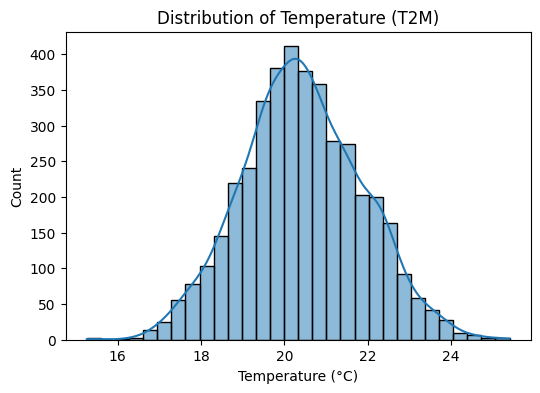

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df["T2M"], bins=30, kde=True)
plt.title("Distribution of Temperature (T2M)")
plt.xlabel("Temperature (°C)")
plt.show()

### Temperature Distribution Interpretation

The temperature distribution is approximately normal (bell-shaped).
Most temperatures are concentrated between 19°C and 22°C.
Extreme low and high temperatures occur less frequently.
Insight

This shows that Kenya generally experiences stable and moderate temperatures throughout the year.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

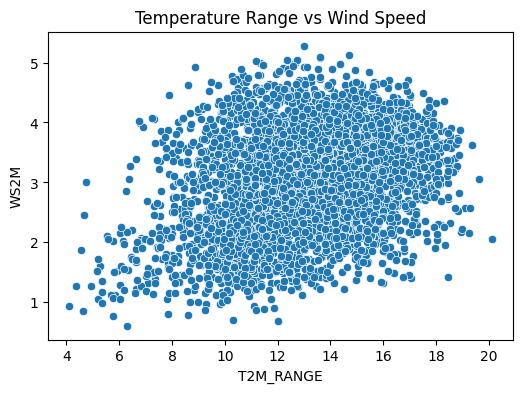

In [22]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.show()

### Temperature Range vs Wind Speed Insight

The scatter plot shows a weak positive relationship between temperature range and wind speed.
As temperature range increases, wind speed slightly increases.
Most observations are concentrated between 10–16°C temperature range and 2–4 m/s wind speed.
Insight

This suggests that changes in temperature range have only a small effect on wind speed in Kenya.

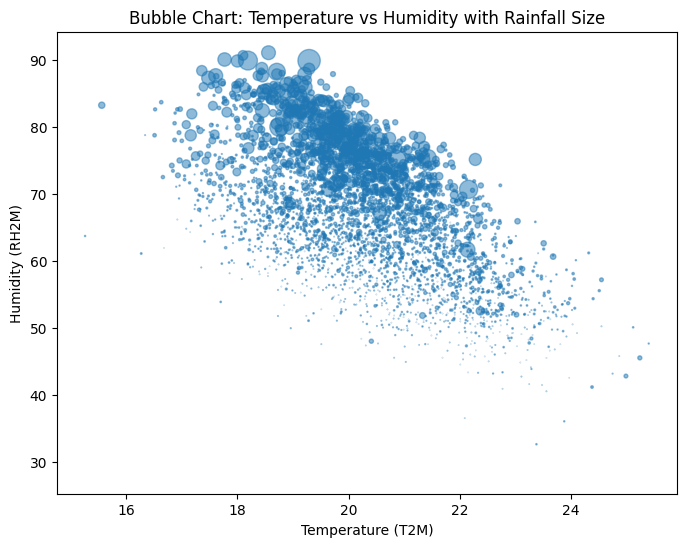

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*5,
    alpha=0.5
)

plt.title("Bubble Chart: Temperature vs Humidity with Rainfall Size")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

### Bubble Chart Insight

The chart shows a negative relationship between temperature and humidity.
As temperature increases, humidity generally decreases.
Larger bubbles represent higher rainfall levels.
Higher rainfall mostly occurs when humidity is high and temperatures are moderate.
Insight

This suggests that rainfall in Kenya is more common during humid conditions rather than very hot temperatures.

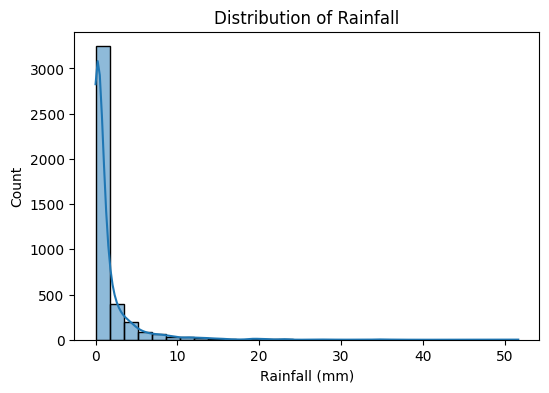

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.show()

### Rainfall Distribution Interpretation
The rainfall distribution is highly right-skewed.
Most days recorded very low or no rainfall.
A few days experienced heavy rainfall events above 20 mm.
Insight

This shows that Kenya has many dry days with occasional heavy rainfall periods.

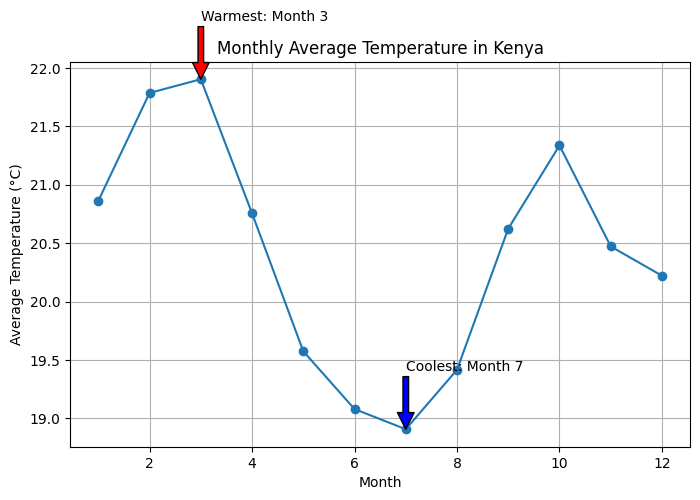

In [28]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")

# Find warmest month
warmest_month = monthly_temp.idxmax()
warmest_temp = monthly_temp.max()

# Find coolest month
coolest_month = monthly_temp.idxmin()
coolest_temp = monthly_temp.min()

# Annotate warmest month
plt.annotate(
    f"Warmest: Month {warmest_month}",
    xy=(warmest_month, warmest_temp),
    xytext=(warmest_month, warmest_temp+0.5),
    arrowprops=dict(facecolor='red')
)

# Annotate coolest month
plt.annotate(
    f"Coolest: Month {coolest_month}",
    xy=(coolest_month, coolest_temp),
    xytext=(coolest_month, coolest_temp+0.5),
    arrowprops=dict(facecolor='blue')
)

plt.title("Monthly Average Temperature in Kenya")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

### Monthly Temperature Trend Interpretation

Temperature increases from January to March.


March (Month 3) is the warmest month (~21.9°C).


Temperature decreases from April to July.


July (Month 7) is the coolest month (~18.9°C).


Temperature rises again from August to October before slightly decreasing toward December.


Insight
Kenya experiences relatively stable temperatures throughout the year with moderate seasonal changes.

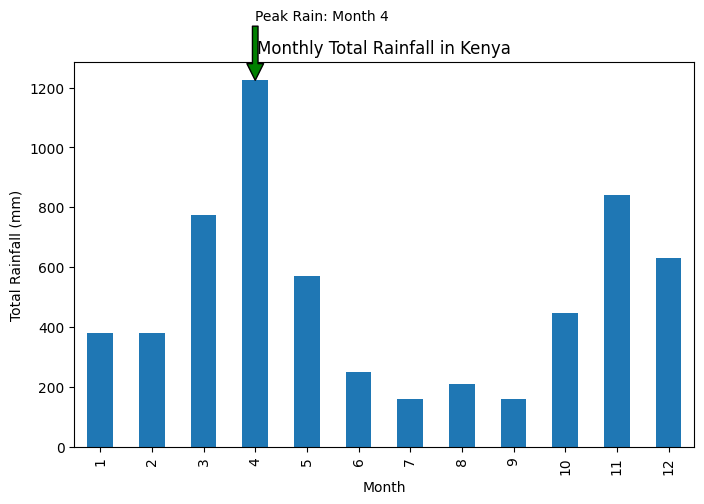

In [26]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(8,5))
monthly_rain.plot(kind="bar")

# Peak rainfall month
peak_month = monthly_rain.idxmax()
peak_rain = monthly_rain.max()

plt.annotate(
    f"Peak Rain: Month {peak_month}",
    xy=(peak_month-1, peak_rain),
    xytext=(peak_month-1, peak_rain+200),
    arrowprops=dict(facecolor='green')
)

plt.title("Monthly Total Rainfall in Kenya")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.show()

### Monthly Rainfall Trend Interpretation

Rainfall increases from January to April.
April (Month 4) records the highest rainfall (peak rainy month).
Rainfall decreases from May to September.
Rainfall rises again in October to December, with another noticeable peak in November.
Insight

Kenya shows two rainy seasons, with the main rainy season in March–May and another rainy period in October–December.

# Final EDA Summary

## Data Cleaning

Loaded Kenya climate dataset successfully.
Converted YEAR and DOY into a proper Date column.
Created a Month column for monthly analysis.
Replaced invalid -999 values with NaN.
No duplicate rows were found.
No missing values remained after cleaning.
Cleaned dataset was exported successfully.
## Descriptive Statistics
Dataset contains 4,108 records.
Average temperature: ~20.4°C
Average humidity: ~65.8%
Average rainfall: ~1.47 mm
Maximum temperature reached 34.27°C.

## Outlier Analysis
-Detected 121 outlier rows using the Z-score method.
These may represent extreme weather conditions.
## Monthly Trends
-Temperature peaks in March.
Lowest temperature occurs in July.
Rainfall peaks in April.
Another rainy season appears in November–December.

## Correlation Insights
-Temperature and maximum temperature show a strong positive relationship.
Rainfall and humidity have a positive relationship.
Temperature and humidity show a negative relationship.

## Distribution Insights
-Temperature follows an approximately normal distribution.
Rainfall is right-skewed, showing many low-rainfall days and few heavy rainfall events.
## Conclusion
Kenya has a relatively stable climate with moderate temperatures throughout the year and two noticeable rainy seasons. The dataset is clean and suitable for climate trend analysis.